## 1. Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score, TimeSeriesSplit
from sklearn.metrics import r2_score

pd.set_option("display.max_columns", 1000)

## 2. Data Loading & Cleaning

In [ ]:
df = pd.read_csv('data/clean/final_featuresv2.csv')
df.sort_values(by="date")
exclude_cols = [
    'state', 'date', 'inpatient_beds', 'inpatient_beds_used', "hospital_inpatient_beds", 
    "inpatient_beds_utilization_normalized"
]
columns_of_interest = [c for c in df.columns if c not in exclude_cols]

df = df[columns_of_interest].dropna().copy()

,previous_day_admission_adult_covid_suspected_80_,on_hand_supply_therapeutic_a_casirivimab_imdevimab_courses,on_hand_supply_therapeutic_b_bamlanivimab_courses,on_hand_supply_therapeutic_c_bamlanivimab_etesevimab_courses,previous_week_therapeutic_a_casirivimab_imdevimab_courses_used,previous_week_therapeutic_b_bamlanivimab_courses_used,previous_week_therapeutic_c_bamlanivimab_etesevimab_courses_used,icu_patients_confirmed_influenza,coverage_per_state,hospital_covid_deaths,state_staffing_shortage_ratio,state_staffing_reporting_completeness,state_staffing_shortage_anticipation_ratio,state_staffing_shortage_anticipation_completeness,hospital_inpatient_beds_used,hospital_patients_hospitalized_confirmed_influenza_and_covid,previous_day_admission_adult_covid_confirmed_normalized,previous_day_admission_adult_covid_suspected_normalized,previous_day_admission_pediatric_covid_confirmed_normalized,previous_day_admission_pediatric_covid_suspected_normalized,previous_day_admission_adult_covid_confirmed_18_19_normalized,previous_day_admission_adult_covid_confirmed_20_29_normalized,previous_day_admission_adult_covid_confirmed_30_39_normalized,previous_day_admission_adult_covid_confirmed_40_49_normalized,previous_day_admission_adult_covid_confirmed_50_59_normalized,previous_day_admission_adult_covid_confirmed_60_69_normalized,previous_day_admission_adult_covid_confirmed_70_79_normalized,previous_day_admission_adult_covid_confirmed_80_normalized,previous_day_admission_adult_covid_confirmed_unknown_normalized,previous_day_admission_adult_covid_suspected_18_19_normalized,previous_day_admission_adult_covid_suspected_20_29_normalized,previous_day_admission_adult_covid_suspected_30_39_normalized,previous_day_admission_adult_covid_suspected_40_49_normalized,previous_day_admission_adult_covid_suspected_50_59_normalized,previous_day_admission_adult_covid_suspected_60_69_normalized,previous_day_admission_adult_covid_suspected_70_79_normalized,previous_day_admission_adult_covid_suspected_80_normalized,previous_day_admission_adult_covid_suspected_unknown_normalized,previous_day_admission_influenza_confirmed_normalized,previous_day_deaths_covid_and_influenza_normalized,previous_day_deaths_influenza_normalized,previous_day_admission_pediatric_covid_confirmed_0_4_normalized,previous_day_admission_pediatric_covid_confirmed_12_17_normalized,previous_day_admission_pediatric_covid_confirmed_5_11_normalized,previous_day_admission_pediatric_covid_confirmed_unknown_normalized
36260,36.0,2750.0,2705.0,3422.0,636.0,18.0,847.0,4.0,206,0.515789,0.083799,0.868932,0.100559,0.868932,112.014563,0.059880,4.752427,1.417910,0.149254,0.154229,0.058824,0.341709,0.440000,0.386935,0.701493,0.855000,0.914141,0.885000,0.329949,0.010050,0.082474,0.128205,0.112821,0.149485,0.235897,0.276923,0.185567,0.291667,0.011236,0.0,0.0,0.000000,0.000000,0.0,0.666667
36299,0.0,499.0,150.0,655.0,43.0,0.0,67.0,2.0,24,0.000000,0.043478,0.958333,0.086957,0.958333,51.458333,0.000000,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.130435,0.043478,0.000000,0.086957,0.086957,0.173913,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000
36314,40.0,2843.0,2342.0,3411.0,698.0,18.0,1071.0,2.0,206,0.453039,0.089385,0.868932,0.123596,0.864078,109.427184,0.054422,4.441748,1.522388,0.154229,0.134328,0.029851,0.263959,0.392857,0.408163,0.666667,0.862944,0.843434,0.863636,0.291262,0.010050,0.119171,0.125000,0.109375,0.166667,0.295337,0.248705,0.207254,0.293532,0.011494,0.0,0.0,0.000000,0.000000,0.0,0.800000
36324,35.0,2107.0,404.0,751.0,817.0,0.0,286.0,7.0,141,0.277778,0.318966,0.822695,0.370690,0.822695,101.056738,0.087719,2.553191,1.087591,0.131387,0.182482,0.036765,0.200000,0.189781,0.362963,0.485507,0.540146,0.401460,0.397059,0.021277,0.022556,0.090909,0.090909,0.099237,0.137405,0.282443,0.145038,0.265152,0.000000,0.030534,0.0,0.0,0.000000,0.000000,0.0,1.250000
36325,2.0,774.0,433.0,394.0,2131.0,150.0,663.0,2.0,110,0.

## 3. Random Forest — Predicting `inpatient_beds_used`

In [ ]:
# train_ind = round(0.8 * len(df))
# train_mat = df.iloc[0:train_ind, ]

# test_mat = df.iloc[train_ind:, ]
# test_y = test_mat["hospital_inpatient_beds_used"]
# test_X = test_mat.drop(columns = ["hospital_inpatient_beds_used"])

# train_y = train_mat["hospital_inpatient_beds_used"]
# train_X = train_mat.drop(columns= "hospital_inpatient_beds_used")

# rfr = RandomForestRegressor(random_state=SEED)
# rfr.fit(train_X, train_y)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
# r2_train = r2_score(y_train, rfr.predict(X_train))
# r2_test  = r2_score(y_test,  rfr.predict(X_test))

# print(f"Train R²: {r2_train:.4f}")
# print(f"Test  R²: {r2_test:.4f}")
# print(f"Gap:      {r2_train - r2_test:.4f}  (>0.05 suggests overfitting)")

Train R²: 0.9504
Test  R²: 0.9973
Gap:      -0.0470  (>0.05 suggests overfitting)


### 3.1 Train vs Test R² (Overfitting Check)

### 3.2 Cross-Validated R²

In [20]:
len(X.columns)

44

In [21]:
rfrv2 = RandomForestRegressor(random_state=SEED, max_features= "sqrt")
tscv = TimeSeriesSplit(n_splits=5)
cv_scores = cross_val_score(rfrv2, X, y, cv=tscv, scoring='r2')

print(f"CV R² scores: {cv_scores.round(4)}")
print(f"Mean: {cv_scores.mean():.4f}  |  Std: {cv_scores.std():.4f}")

CV R² scores: [0.8867 0.7431 0.612  0.7301 0.8404]
Mean: 0.7625  |  Std: 0.0955


### True values vs Predicted

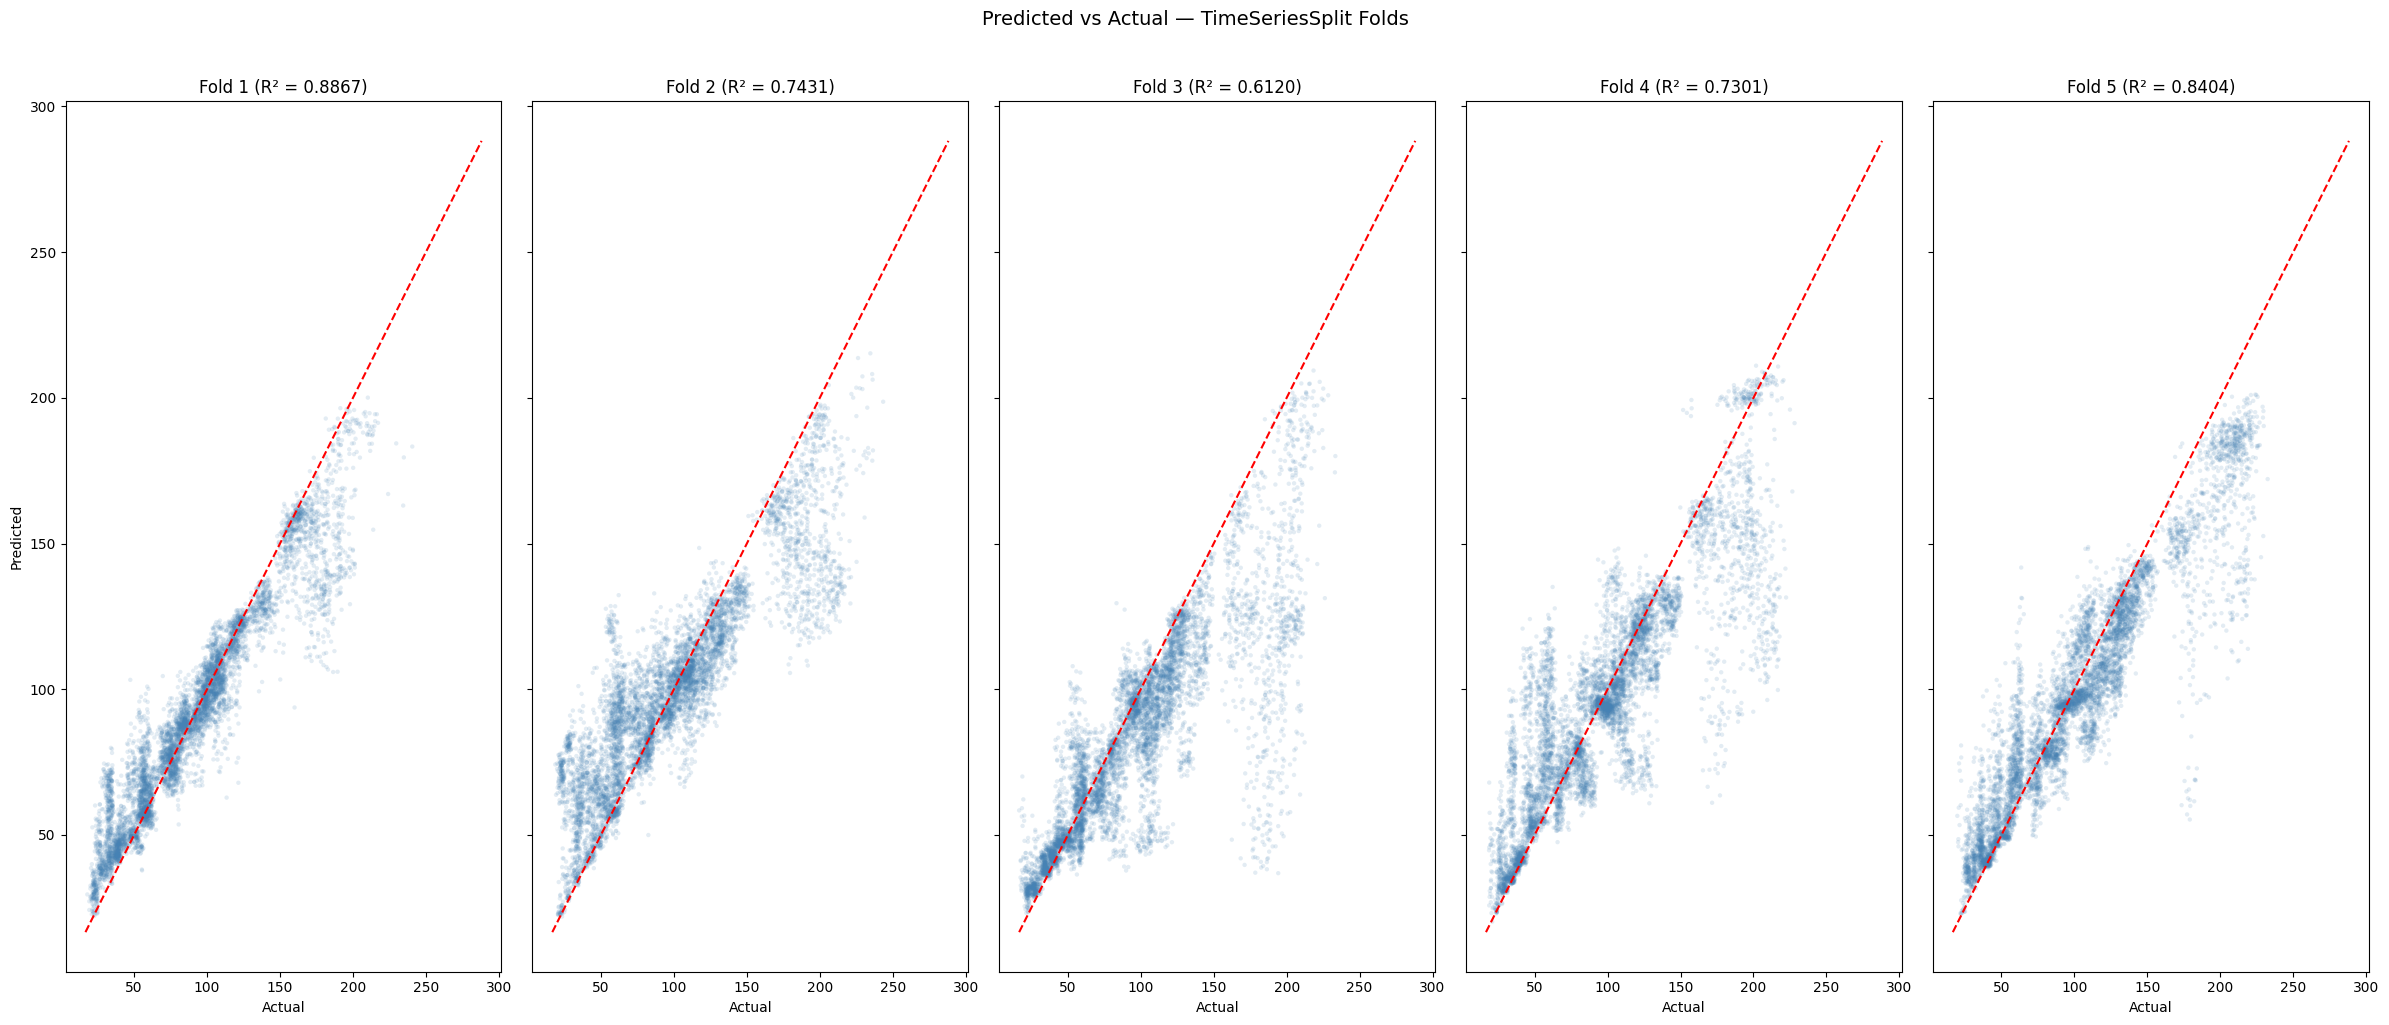

In [24]:
# Predicted vs Actual for each TimeSeriesSplit fold
tscv = TimeSeriesSplit(n_splits=5)

fig, axes = plt.subplots(1, 5, figsize=(24, 10), sharex=True, sharey=True)

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    rf_fold = RandomForestRegressor(random_state=SEED, max_features= "sqrt")
    rf_fold.fit(X_tr, y_tr)
    y_pred_fold = rf_fold.predict(X_te)

    r2_fold = r2_score(y_te, y_pred_fold)

    ax = axes[fold]
    ax.scatter(y_te, y_pred_fold, alpha=0.15, s=10, color='steelblue', edgecolors='none')

    lo = min(y.min(), y_pred_fold.min())
    hi = max(y.max(), y_pred_fold.max())
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1.5)

    ax.set_title(f'Fold {fold + 1} (R² = {r2_fold:.4f})')
    ax.set_xlabel('Actual')
    if fold == 0:
        ax.set_ylabel('Predicted')

fig.suptitle('Predicted vs Actual — TimeSeriesSplit Folds', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()